In [1]:
import pygmo as pg
import numpy as np
import os
import sys
sys.path.append("/home/jlgpke/projects/UCL/research_project/topological_insulator/notebooks/project/")
from topological_insulator import Problem
from mean_field_problem import MeanFieldProblem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "honeycomb.json"

In [3]:
# occupations_ini = [
#     0, 0, 0.1, 0, 0.1, 0, 0.8, 0,
#     0, 0, 0, 0.1, 0, 0.1, 0, 0.8
# ]
occupations_ini = np.zeros(16)


In [4]:
mean_field_problem = MeanFieldProblem(
    structure_path, structure_name, Delta_SOC=-5,
    t=1, U=3, delta=0.83, occupations=occupations_ini
)

In [5]:
problem = Problem(
            structure_path=structure_path, structure_name=structure_name)
mean_field_problem._set_eigenvalues(problem, occupations_ini)
problem.setup(
    N_r = 10,
    N_k = 200,
    location = "bulk",
    BZ = "reduced"
)
problem.run(
    H_type="reciprocal"
)
g = problem.geometry
tb_bulk = problem.hamiltonian["bulk"]["tight_binding"]
invariants = problem.hamiltonian["bulk"]["topological_invariants"]

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


In [6]:
j_3_2 = [8, 9, 10, 11, 12, 13, 14, 15]
bands = [12, 13, 14, 15]

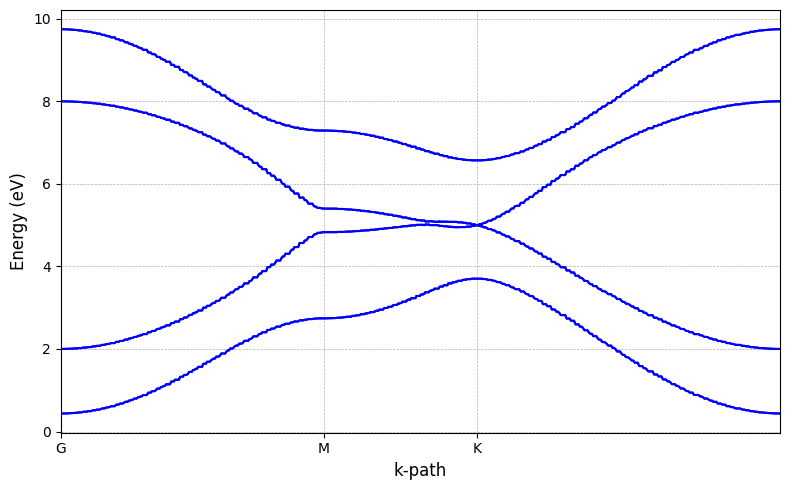

In [7]:
tb_bulk.plot_band_structure(g, j_3_2)

In [8]:
E, DOS = mean_field_problem.density_of_states(g, tb_bulk, invariants, E_max=10, E_min=1)

In [20]:
mean_field_problem.bz_mask[0, 0] # Check for -pi, -pi point

np.False_

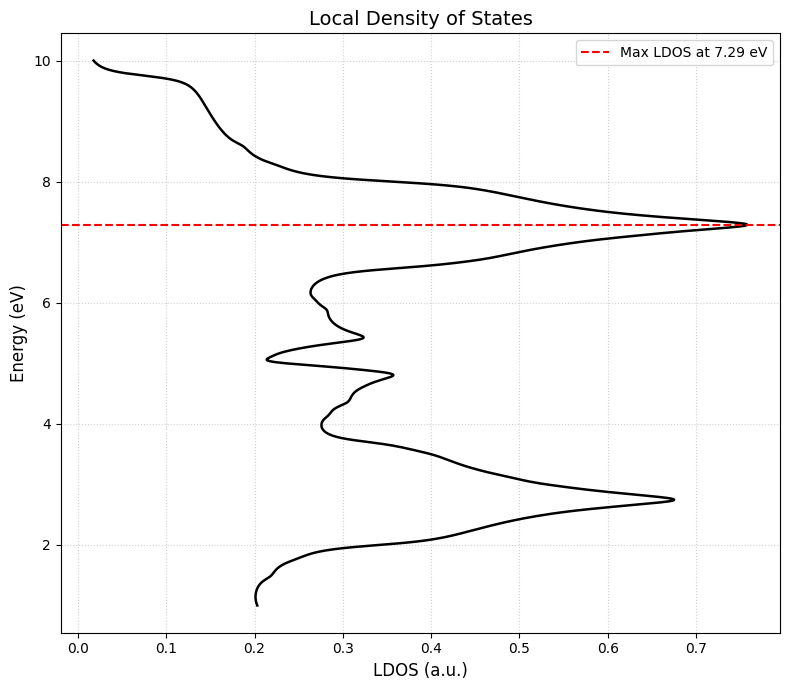

In [9]:
invariants.plot_density_of_states(E, DOS)

In [10]:
mu = mean_field_problem.find_chemical_potential(E, DOS, 2, mu_min=5, mu_max=10)
print(f"mu = {mu}")

mu = 6.827306859036245


In [12]:
tol = 1e-5
occupations_old  = np.zeros(16)
converged = False
counter = 0
results = {}
while not converged:
    mean_field_problem = MeanFieldProblem(
    structure_path, structure_name, Delta_SOC=-5,
    t=1, U=3, delta=0.832, occupations=occupations_old
    )
    occupations_new, mu = mean_field_problem._objective(
        occupations=occupations_old, 
        E_max=10, 
        E_min=1, 
        eta=0.08, 
        mu_max=10, 
        mu_min=5, 
        T=300, 
        N_e =2
    )
    results[counter] = occupations_new
    diff = np.abs(occupations_old - occupations_new)
    print(counter, diff)
    converged = np.all(diff < tol)
    occupations_old = occupations_new
    counter +=1


Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
0 [0.38653502 0.38653502 0.30910633 0.30906255 0.30912601 0.30902148
 0.28650254 0.28634418 0.38653502 0.38653502 0.30906255 0.30910633
 0.30902148 0.30912601 0.28634418 0.28650254]

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
1 [0.         0.         0.01922176 0.01681508 0.01872274 0.01573433
 0.01212037 0.01255084 0.         0.         0.02023621 0.01659376
 0.01880361 0.01056423 0.01163167 0.01103876]

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
2 [0.00000000e+00 0.00000000e+00 3.02147685e-03 2.84799352e-03
 2.90577354e-03 3.06404865e-03 2.32652060e-03 2.44238497e-03
 1.11022302e-16 0.00000000e+00 3.13080

In [14]:
print(occupations_new, mu)

[0.38653502 0.38653502 0.33205747 0.32944914 0.33140565 0.32859229
 0.30149766 0.30191089 0.38653502 0.38653502 0.33314855 0.32945969
 0.33111578 0.32526639 0.3011074  0.30014496] 6.273238138041464
